In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
daily_activity = pd.read_csv(r'E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\dailyActivity_merged.csv')
heart_rate = pd.read_csv(r"E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\heartrate_seconds_merged.csv")
hourly_calories = pd.read_csv(r'E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\hourlyCalories_merged.csv')
hourly_intensities = pd.read_csv(r"E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\hourlyIntensities_merged.csv")
hourly_steps = pd.read_csv(r"E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\hourlySteps_merged.csv")
mets = pd.read_csv(r"E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\minuteMETsNarrow_merged.csv")
sleep = pd.read_csv(r"E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\sleepDay_merged.csv")
weight = pd.read_csv(r"E:\Fit\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\weightLogInfo_merged.csv")

Check

In [3]:
 daily_activity.info()
 daily_activity.isnull().sum()
 daily_activity.duplicated().sum()


<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    str    
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories             

np.int64(0)

In [ ]:
heart_rate.info()
heart_rate.isnull().sum()
heart_rate.duplicated().sum()

np.int64(0)

In [ ]:
hourly_calories.info()
hourly_calories.isnull().sum()
hourly_calories.duplicated().sum()

In [ ]:
hourly_intensities.info()
hourly_calories.isnull().sum()
hourly_calories.duplicated().sum()

In [ ]:
hourly_steps.info()
hourly_steps.isnull().sum()
hourly_steps.duplicated().sum()

In [ ]:
mets.info()
mets.isnull().sum()
mets.duplicated().sum()

In [ ]:
sleep.info()
sleep.isnull().sum()
sleep.duplicated().sum()

In [ ]:
weight.info()
weight.isnull().sum()
weight.duplicated().sum()

## EDA

### Distribution of Steps

<Axes: >

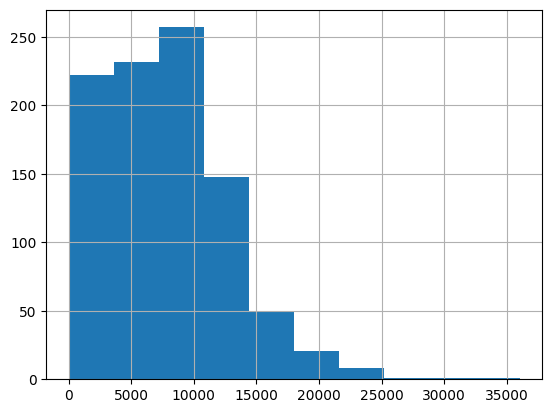

In [6]:
daily_activity['TotalSteps'].hist()

### Distribution of Calories

<Axes: >

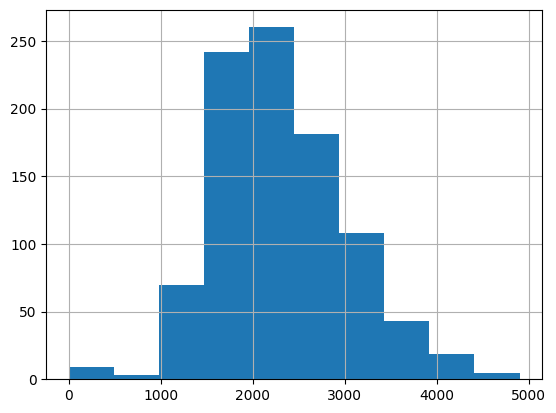

In [7]:
daily_activity['Calories'].hist()

### Correlation Analysis

In [4]:
cols = ['TotalSteps', 'TotalDistance', 'Calories', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']

daily_activity[cols].corr()

,TotalSteps,TotalDistance,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes
TotalSteps,1.000000,0.985369,0.591568,0.667079,0.498693,0.569600,-0.327484
TotalDistance,0.985369,1.000000,0.644962,0.681297,0.462899,0.516300,-0.288094
Calories,0.591568,0.644962,1.000000,0.615838,0.297623,0.286718,-0.106973
VeryActiveMinutes,0.667079,0.681297,0.615838,1.000000,0.312420,0.051926,-0.164671
FairlyActiveMinutes,0.498693,0.462899,0.297623,0.312420,1.000000,0.148820,-0.237446
LightlyActiveMinutes,0.569600,0.516300,0.286718,0.051926,0.148820,1.000000,-0.437104
SedentaryMinutes,-0.327484,-0.288094,-0.106973,-0.164671,-0.237446,-0.437104,1.000000


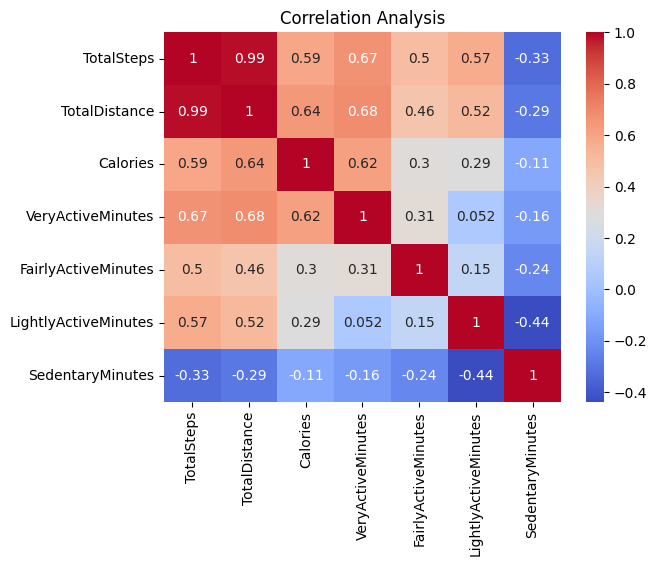

In [5]:
sns.heatmap(daily_activity[cols].corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Analysis')
plt.show()

### Activity Level Segmentation

In [6]:
result = daily_activity.groupby('Id').agg({'TotalSteps' : 'mean', 'Calories' : 'mean', 'TotalDistance' : 'mean'}).reset_index()

def classify_steps(x):
    if x < 5000 :
        return 'Sedentary'
    elif x < 7500:
        return 'Low Active'
    elif x < 10000:
        return 'Somewhat Active'
    elif x < 12500:
        return 'Active'
    else:
        return 'Highly Active'

result['Activity_level'] = result['TotalSteps'].apply(classify_steps)
result



,Id,TotalSteps,Calories,TotalDistance,Activity_level
0,1503960366,12116.741935,1816.419355,7.809677,Active
1,1624580081,5743.903226,1483.354839,3.914839,Low Active
2,1644430081,7282.966667,2811.300000,5.295333,Low Active
3,1844505072,2580.064516,1573.483871,1.706129,Sedentary
4,1927972279,916.129032,2172.806452,0.634516,Sedentary
5,2022484408,11370.645161,2509.967742,8.084193,Active
6,2026352035,5566.870968,1540.645161,3.454839,Low Active
7,2320127002,4716.870968,1724.161290,3.187742,Sedentary
8,2347167796,9519.666667,2043.444444,6.355556,Somewhat Active
9,2873212765,7555.774194,1916.967742,5.101613,Somewhat Active


In [7]:
fig = px.scatter(daily_activity, x = 'TotalSteps', y= 'Calories', title = 'Activity Vs Calories')
fig.show()


### Sleep Analysis (Activity vs Sleep)

In [9]:
dactivity = daily_activity.groupby('Id').agg({'TotalSteps' : 'mean', 'TotalDistance' :'mean'}).reset_index()

sp = sleep.groupby('Id').agg({'TotalSleepRecords' : 'mean', 'TotalMinutesAsleep' : 'mean', 'TotalTimeInBed' : 'mean'}).reset_index()

sleep_analysis = pd.merge(dactivity, sp, on = 'Id', how = 'inner')

sleep_analysis

,Id,TotalSteps,TotalDistance,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,12116.741935,7.809677,1.080000,360.280000,383.200000
1,1644430081,7282.966667,5.295333,1.000000,294.000000,346.000000
2,1844505072,2580.064516,1.706129,1.000000,652.000000,961.000000
3,1927972279,916.129032,0.634516,1.600000,417.000000,437.800000
4,2026352035,5566.870968,3.454839,1.000000,506.178571,537.642857
5,2320127002,4716.870968,3.187742,1.000000,61.000000,69.000000
6,2347167796,9519.666667,6.355556,1.000000,446.800000,491.333333
7,3977333714,10984.566667,7.517000,1.142857,293.642857,461.142857
8,4020332650,2267.225806,1.626129,1.000000,349.375000,379.750000
9,4319703577,7268.838710,4.892258,1.038462,476.653846,501.961538


### Heart Rate Analysis (Activity vs Heart Rate)

In [10]:
heart_rate['Time'] = pd.to_datetime(heart_rate['Time']) 

In [11]:
heart_rate['date_hour'] = heart_rate['Time'].dt.floor('h')
heart_rate['date_hour'] = pd.to_datetime(heart_rate['date_hour'])
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])

In [12]:
hrt_rate = heart_rate.groupby(['Id', 'date_hour']).agg({'Value' : 'mean'}).reset_index()

heart_analysis = pd.merge(hrt_rate, hourly_steps, left_on = ['Id', 'date_hour'], right_on = ['ID', 'ActivityHour'], how = 'inner')

heart_analysis[['Id', 'date_hour', 'Value', 'StepTotal']]


,Id,date_hour,Value,StepTotal
0,2022484408,2016-04-12 07:00:00,83.200000,847
1,2022484408,2016-04-12 08:00:00,68.562005,334
2,2022484408,2016-04-12 09:00:00,66.404700,243
3,2022484408,2016-04-12 10:00:00,106.716075,5243
4,2022484408,2016-04-12 11:00:00,67.767157,323
...,...,...,...,...
6001,8877689391,2016-05-12 10:00:00,68.733503,514
6002,8877689391,2016-05-12 11:00:00,72.030108,1407
6003,8877689391,2016-05-12 12:00:00,87.614719,3135
6004,8877689391,2016-05-12 13:00:00,64.737705,307


### BMI Vs Activity 

In [13]:
activity = daily_activity.groupby('Id').agg({'TotalSteps' : 'mean', 'TotalDistance' : 'mean'}).reset_index()

wgt = weight.groupby('Id').agg({'WeightKg' : 'mean', 'BMI' : 'mean'}).reset_index()

def bm(x):
    if x < 18.5 :
        return 'UnderWeight'
    elif x < 25 :
        return 'Normal'
    elif x < 30 :
        return 'OverWeight'
    else:
        return 'Obese'
    
wgt['Bmi_category'] = wgt['BMI'].apply(bm) 

bmi_activity = pd.merge(activity, wgt, on = 'Id', how = 'inner')

bmi_activity

,Id,TotalSteps,TotalDistance,WeightKg,BMI,Bmi_category
0,1503960366,12116.741935,7.809677,52.599998,22.650000,Normal
1,1927972279,916.129032,0.634516,133.500000,47.540001,Obese
2,2873212765,7555.774194,5.101613,57.000000,21.570001,Normal
3,4319703577,7268.838710,4.892258,72.350002,27.415000,OverWeight
4,4558609924,7685.129032,5.080645,69.639999,27.214000,OverWeight
5,5577150313,8304.433333,6.213333,90.699997,28.000000,OverWeight
6,6962181067,9794.806452,6.585806,61.553334,24.028000,Normal
7,8877689391,16040.032258,13.212903,85.145834,25.487083,OverWeight


In [14]:
fig2 = px.scatter(bmi_activity, x = 'BMI', y = 'TotalSteps', title = 'BMI Analysis')
fig2.show()

### Intensity Vs Calories

In [15]:
intensity_calories = pd.merge(hourly_intensities, hourly_calories, left_on = ['Id', 'ActivityHour'], right_on = ['Id', 'ActivityHour'], how = 'inner')

intensity_calories

,Id,ActivityHour,TotalIntensity,AverageIntensity,Calories
0,1503960366,4/12/2016 12:00:00 AM,20,0.333333,81
1,1503960366,4/12/2016 1:00:00 AM,8,0.133333,61
2,1503960366,4/12/2016 2:00:00 AM,7,0.116667,59
3,1503960366,4/12/2016 3:00:00 AM,0,0.000000,47
4,1503960366,4/12/2016 4:00:00 AM,0,0.000000,48
...,...,...,...,...,...
22094,8877689391,5/12/2016 10:00:00 AM,12,0.200000,126
22095,8877689391,5/12/2016 11:00:00 AM,29,0.483333,192
22096,8877689391,5/12/2016 12:00:00 PM,93,1.550000,321
22097,8877689391,5/12/2016 1:00:00 PM,6,0.100000,101


### METs Vs Intensity

In [16]:
mets['ActivityMinute'] = pd.to_datetime(mets['ActivityMinute'])

C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_3408\3523556010.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mets['ActivityMinute'] = pd.to_datetime(mets['ActivityMinute'])


In [17]:
mets['date_hour'] = mets['ActivityMinute'].dt.floor('h')

In [18]:
mets['date_hour'] = pd.to_datetime(mets['date_hour'])
hourly_intensities['ActivityHour'] = pd.to_datetime(hourly_intensities['ActivityHour'])

C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_3408\1365063452.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_intensities['ActivityHour'] = pd.to_datetime(hourly_intensities['ActivityHour'])


In [19]:
mts = mets.groupby(['Id', 'date_hour']).agg({'METs' : 'mean'}).reset_index()

mets_intensity = pd.merge(hourly_intensities, mts, left_on = ['Id', 'ActivityHour'], right_on = ['Id', 'date_hour'], how = 'inner')

mets_intensity['METs'] = mets_intensity['METs']/10

mets_intensity

,Id,ActivityHour,TotalIntensity,AverageIntensity,date_hour,METs
0,1503960366,2016-04-12 00:00:00,20,0.333333,2016-04-12 00:00:00,1.723333
1,1503960366,2016-04-12 01:00:00,8,0.133333,2016-04-12 01:00:00,1.283333
2,1503960366,2016-04-12 02:00:00,7,0.116667,2016-04-12 02:00:00,1.246667
3,1503960366,2016-04-12 03:00:00,0,0.000000,2016-04-12 03:00:00,1.000000
4,1503960366,2016-04-12 04:00:00,0,0.000000,2016-04-12 04:00:00,1.006667
...,...,...,...,...,...,...
22088,8877689391,2016-05-12 09:00:00,4,0.066667,2016-05-12 09:00:00,1.211667
22089,8877689391,2016-05-12 10:00:00,12,0.200000,2016-05-12 10:00:00,1.733333
22090,8877689391,2016-05-12 11:00:00,29,0.483333,2016-05-12 11:00:00,2.643333
22091,8877689391,2016-05-12 12:00:00,93,1.550000,2016-05-12 12:00:00,4.410000


### METs Vs Calories

In [20]:
hourly_calories['ActivityHour'] = pd.to_datetime(hourly_calories['ActivityHour'])


C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_3408\772100266.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_calories['ActivityHour'] = pd.to_datetime(hourly_calories['ActivityHour'])


In [21]:
mets_calories = pd.merge(hourly_calories, mts, left_on = ['Id', 'ActivityHour'], right_on = ['Id', 'date_hour'], how = 'inner')

mets_calories['METs'] = mets_calories['METs']/10

mets_calories

,Id,ActivityHour,Calories,date_hour,METs
0,1503960366,2016-04-12 00:00:00,81,2016-04-12 00:00:00,1.723333
1,1503960366,2016-04-12 01:00:00,61,2016-04-12 01:00:00,1.283333
2,1503960366,2016-04-12 02:00:00,59,2016-04-12 02:00:00,1.246667
3,1503960366,2016-04-12 03:00:00,47,2016-04-12 03:00:00,1.000000
4,1503960366,2016-04-12 04:00:00,48,2016-04-12 04:00:00,1.006667
...,...,...,...,...,...
22088,8877689391,2016-05-12 09:00:00,88,2016-05-12 09:00:00,1.211667
22089,8877689391,2016-05-12 10:00:00,126,2016-05-12 10:00:00,1.733333
22090,8877689391,2016-05-12 11:00:00,192,2016-05-12 11:00:00,2.643333
22091,8877689391,2016-05-12 12:00:00,321,2016-05-12 12:00:00,4.410000


### Time Series Analysis

<Axes: xlabel='ActivityDate'>

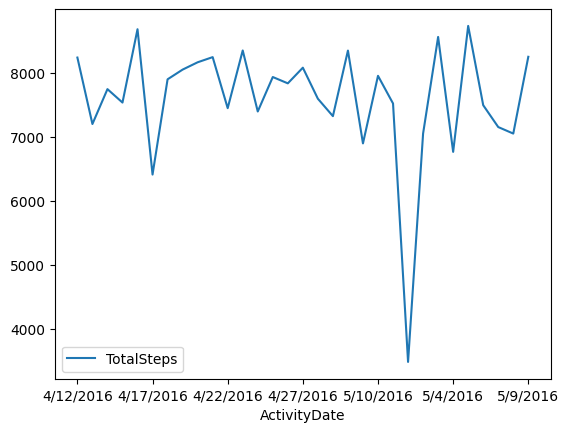

In [22]:
daily_activity.groupby('ActivityDate').agg({'TotalSteps' : 'mean'}).plot()



## Total Analysis

In [23]:
hourly_intensities['ActivityHour'] = pd.to_datetime(hourly_intensities['ActivityHour'])

In [24]:
d_analysis = daily_activity.groupby('Id').agg(Average_Steps = ('TotalSteps', 'mean'), Average_Distance = ('TotalDistance', 'mean'),
                                              Average_Calories_Burned = ('Calories', 'mean')).reset_index()

i_analysis = hourly_intensities.groupby('Id').agg(Average_Intensity = ('TotalIntensity', 'mean')).reset_index()

h_analysis = hrt_rate.groupby('Id').agg(Heart_Rate = ('Value', 'mean')).reset_index()

m_analysis = mts.groupby('Id').agg(Average_Mets = ('METs', 'mean')).reset_index()

m_analysis['Average_Mets'] = m_analysis['Average_Mets']/10

s_analysis = sleep.groupby('Id').agg(Average_Sleep_record = ('TotalSleepRecords', 'mean'), Average_Minutes_Sleep = ('TotalMinutesAsleep', 'mean')
                                     , Average_Time_In_Bed = ('TotalTimeInBed', 'mean')).reset_index()

w_analysis = weight.groupby('Id').agg({'WeightKg' : 'mean', 'BMI' : 'mean'}).reset_index()

In [25]:
Final_Analysis = d_analysis.merge(i_analysis, on = 'Id', how = 'left')\
                 .merge(h_analysis, on = 'Id', how = 'left') \
                 .merge(m_analysis, on = 'Id', how = 'left') \
                 .merge(s_analysis, on = 'Id', how = 'left') \
                 .merge(w_analysis, on = 'Id', how = 'left')

Final_Analysis

,Id,Average_Steps,Average_Distance,Average_Calories_Burned,Average_Intensity,Heart_Rate,Average_Mets,Average_Sleep_record,Average_Minutes_Sleep,Average_Time_In_Bed,WeightKg,BMI
0,1503960366,12116.741935,7.809677,1816.419355,16.170153,NaN,1.666855,1.080000,360.280000,383.200000,52.599998,22.650000
1,1624580081,5743.903226,3.914839,1483.354839,8.039402,NaN,1.252201,NaN,NaN,NaN,NaN,NaN
2,1644430081,7282.966667,5.295333,2811.300000,10.519774,NaN,1.410767,1.000000,294.000000,346.000000,NaN,NaN
3,1844505072,2580.064516,1.706129,1573.483871,5.021888,NaN,1.187798,1.000000,652.000000,961.000000,NaN,NaN
4,1927972279,916.129032,0.634516,2172.806452,1.857337,NaN,1.064828,1.600000,417.000000,437.800000,133.500000,47.540001
5,2022484408,11370.645161,8.084193,2509.967742,17.031250,79.694763,1.695537,NaN,NaN,NaN,NaN,NaN
6,2026352035,5566.870968,3.454839,1540.645161,10.812500,89.280184,1.393684,1.000000,506.178571,537.642857,NaN,NaN
7,2320127002,4716.870968,3.187742,1724.161290,8.742857,NaN,1.316299,1.000000,61.000000,69.000000,NaN,NaN
8,2347167796,9519.666667,6.355556,2043.444444,14.521739,75.051666,1.572049,1.000000,446.800000,491.333333,NaN,NaN
9,2873212765,7555.774194,5.101613,1916.967742,15.101902,NaN,1.528508,NaN,NaN,NaN,57.000000,21.570001
